## 1. ⚙️ Configuration & Structure des dossiers

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, time
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

# ── Chemins ────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath('')
BASE_DIR     = os.path.dirname(NOTEBOOK_DIR)
DATA_DIR     = os.path.join(BASE_DIR, 'data')
MODELS_DIR   = os.path.join(BASE_DIR, 'models')

os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('📂 Structure du projet :')
print(f'   data/    → {DATA_DIR}')
print(f'   models/  → {MODELS_DIR}')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

MEDNOVA_BLUE   = '#1A5276'
MEDNOVA_LIGHT  = '#AED6F1'
MEDNOVA_RED    = '#E74C3C'
MEDNOVA_GREEN  = '#27AE60'
MEDNOVA_ORANGE = '#E67E22'
MEDNOVA_PURPLE = '#8E44AD'

print('\n✅ Librairies importées avec succès')

📂 Structure du projet :
   data/    → C:\Users\HP\Desktop\ing4\MedNova\MedNova\data
   models/  → C:\Users\HP\Desktop\ing4\MedNova\MedNova\models

✅ Librairies importées avec succès


## 2. 📥 Chargement des données

In [18]:
from ucimlrepo import fetch_ucirepo

support2 = fetch_ucirepo(id=880)
df_raw = pd.concat([support2.data.features, support2.data.targets], axis=1)
df_raw.to_csv(os.path.join(DATA_DIR, 'support2.csv'), index=False)

print(f'✅ Dataset chargé → data/support2.csv')
print(f'📊 Dimensions : {df_raw.shape[0]:,} patients × {df_raw.shape[1]} variables')
print(f'\n🎯 Variable cible : death')
print(df_raw['death'].value_counts().rename({0:'Survie', 1:'Décès'}))
print(f'   Taux de décès : {df_raw["death"].mean()*100:.1f}%')
df_raw.head()

✅ Dataset chargé → data/support2.csv
📊 Dimensions : 9,105 patients × 45 variables

🎯 Variable cible : death
death
Décès     6201
Survie    2904
Name: count, dtype: int64
   Taux de décès : 68.1%


,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead,sfdm2
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,...,7.459961,NaN,NaN,NaN,7.0,7.0,7.0,0,0,NaN
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,...,7.250000,NaN,NaN,NaN,NaN,1.0,1.0,1,1,<2 mo. follow-up
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,...,7.459961,NaN,NaN,NaN,1.0,0.0,0.0,1,0,<2 mo. follow-up
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1,0,no(M2 and SIP pres)
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,...,7.509766,NaN,NaN,NaN,NaN,2.0,2.0,0,0,no(M2 and SIP pres)


## 3. 🔧 Prétraitement Avancé

### 3.1 Sélection des features

In [19]:
TARGET = 'death'

EXCLUDE_COLS = [
    'death',               # cible
    'd.time', 'hospdead',  # leakage direct
    'slos',                # durée séjour → leakage
    'charges', 'totcst', 'totmcst',  # coûts → cibles secondaires
    'prg2m', 'prg6m',     # pronostic médecin → trop proche
    'dnrday',
]

missing_pct = df_raw.isnull().mean()
high_missing_cols = missing_pct[missing_pct > 0.5].index.tolist()
print(f'Colonnes supprimées (> 50% manquants) : {high_missing_cols}')
EXCLUDE_COLS += high_missing_cols

feature_cols = [c for c in df_raw.columns if c not in EXCLUDE_COLS]
df = df_raw[feature_cols + [TARGET]].copy()

print(f'\n✅ Features retenues : {len(feature_cols)}')
print(f'   {feature_cols}')

Colonnes supprimées (> 50% manquants) : ['urine', 'adlp']

✅ Features retenues : 35
   ['age', 'sex', 'dzgroup', 'dzclass', 'num.co', 'edu', 'income', 'scoma', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'ca', 'dnr', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'adls', 'adlsc', 'sfdm2']


### 3.2 Séparation numériques / catégorielles

In [20]:
X_raw = df[feature_cols].copy()
y     = df[TARGET].copy()

num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_raw.select_dtypes(include=['object','category']).columns.tolist()

print(f'Variables numériques    : {len(num_cols)}')
print(f'Variables catégorielles : {len(cat_cols)} → {cat_cols}')
print(f'\nDistribution cible :')
print(y.value_counts().rename({0:'Survie', 1:'Décès'}))
print(f'Taux de décès : {y.mean()*100:.1f}%')

Variables numériques    : 27
Variables catégorielles : 8 → ['sex', 'dzgroup', 'dzclass', 'income', 'race', 'ca', 'dnr', 'sfdm2']

Distribution cible :
death
Décès     6201
Survie    2904
Name: count, dtype: int64
Taux de décès : 68.1%


### 3.3 Feature Engineering

In [21]:
print('🔧 Feature Engineering...')

def organ_score(row):
    score = 0
    if 'crea'   in row.index and pd.notna(row['crea'])  : score += int(row['crea']  > 2.0)
    if 'bili'   in row.index and pd.notna(row['bili'])  : score += int(row['bili']  > 2.0)
    if 'urine'  in row.index and pd.notna(row['urine']) : score += int(row['urine'] < 400)
    if 'pafi'   in row.index and pd.notna(row['pafi'])  : score += int(row['pafi']  < 200)
    if 'meanbp' in row.index and pd.notna(row['meanbp']): score += int(row['meanbp']< 60)
    return score

organ_cols = [c for c in ['crea','bili','urine','pafi','meanbp'] if c in X_raw.columns]
if len(organ_cols) >= 2:
    X_raw['organ_failure_score'] = X_raw[organ_cols].apply(organ_score, axis=1)
    num_cols.append('organ_failure_score')
    print('  ✅ organ_failure_score')

if 'crea' in X_raw.columns and 'alb' in X_raw.columns:
    X_raw['crea_alb_ratio'] = X_raw['crea'] / X_raw['alb'].replace(0, np.nan)
    num_cols.append('crea_alb_ratio')
    print('  ✅ crea_alb_ratio')

comorbidity_cols = [c for c in ['diabetes','dementia'] if c in X_raw.columns]
if comorbidity_cols:
    for c in comorbidity_cols: X_raw[c] = pd.to_numeric(X_raw[c], errors='coerce')
    X_raw['comorbidity_count'] = X_raw[comorbidity_cols].sum(axis=1)
    num_cols.append('comorbidity_count')
    print('  ✅ comorbidity_count')

if 'age' in X_raw.columns:
    X_raw['age_group'] = pd.cut(X_raw['age'], bins=[0,40,55,65,75,120],
                                  labels=['<40','40-55','55-65','65-75','>75'])
    cat_cols.append('age_group')
    print('  ✅ age_group')

print(f'\n📊 Features totales après engineering : {X_raw.shape[1]}')

🔧 Feature Engineering...
  ✅ organ_failure_score
  ✅ crea_alb_ratio
  ✅ comorbidity_count
  ✅ age_group

📊 Features totales après engineering : 39


### 3.4 Winsorizing

In [22]:
def winsorize_df(df_in, cols, limits=(0.01, 0.01)):
    df_w = df_in.copy()
    for col in cols:
        if col in df_w.columns:
            non_null = df_w[col].dropna()
            df_w[col] = df_w[col].clip(lower=non_null.quantile(limits[0]),
                                        upper=non_null.quantile(1-limits[1]))
    return df_w

X_win = winsorize_df(X_raw, num_cols, limits=(0.01, 0.01))
print(f'✅ Winsorizing (1%-99%) appliqué sur {len(num_cols)} colonnes numériques')

✅ Winsorizing (1%-99%) appliqué sur 30 colonnes numériques


### 3.5 Pipeline Imputation + Encoding + Scaling

In [23]:
num_cols_final = X_win.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_final = X_win.select_dtypes(include=['object','category']).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,    num_cols_final),
        ('cat', categorical_pipeline, cat_cols_final)
    ], remainder='drop'
)

print('✅ Pipeline défini :')
print(f'   Numériques ({len(num_cols_final)})    → Médiane → RobustScaler')
print(f'   Catégorielles ({len(cat_cols_final)}) → Mode   → OneHotEncoder')

✅ Pipeline défini :
   Numériques (30)    → Médiane → RobustScaler
   Catégorielles (9) → Mode   → OneHotEncoder


## 4. ✂️ Split Train / Test (80/20 Stratifié)

In [24]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_win, y, test_size=0.2, random_state=42, stratify=y
)
X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)

print('✅ Split effectué (stratifié)')
print(f'   Train : {X_train.shape[0]:,} patients (80%) | décès {y_train.mean()*100:.1f}%')
print(f'   Test  : {X_test.shape[0]:,}  patients (20%) | décès {y_test.mean()*100:.1f}%')
print(f'   Features après encoding : {X_train.shape[1]}')

joblib.dump(preprocessor, os.path.join(MODELS_DIR, 'preprocessor.pkl'))
print('\n✅ preprocessor.pkl → models/')

✅ Split effectué (stratifié)
   Train : 7,284 patients (80%) | décès 68.1%
   Test  : 1,821  patients (20%) | décès 68.1%
   Features après encoding : 69

✅ preprocessor.pkl → models/


## 5. 🤖 Entraînement des 5 modèles

In [25]:
models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs'),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost'              : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                            scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                            eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM'             : LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                             class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    'SVM'                  : SVC(probability=True, class_weight='balanced', kernel='rbf', C=1.0, random_state=42)
}
print('✅ 5 modèles définis avec class_weight=balanced')

✅ 5 modèles définis avec class_weight=balanced


In [26]:
trained_models = {}
train_times    = {}

print('🚀 Entraînement...\n')
for name, model in models.items():
    print(f'  ⏳ {name}...', end=' ')
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    trained_models[name] = model
    train_times[name]    = elapsed
    print(f'✅ ({elapsed:.1f}s)')

print('\n🎉 Tous les modèles entraînés !')

🚀 Entraînement...

  ⏳ Régression Logistique... ✅ (1.8s)
  ⏳ Random Forest... ✅ (1.6s)
  ⏳ XGBoost... ✅ (1.3s)
  ⏳ LightGBM... ✅ (0.6s)
  ⏳ SVM... ✅ (41.1s)

🎉 Tous les modèles entraînés !


## 6. 📊 Évaluation Multicritère

In [27]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({'Modèle': name,
        'Accuracy' : round(accuracy_score(y_test, y_pred),   4),
        'Precision': round(precision_score(y_test, y_pred),  4),
        'Recall'   : round(recall_score(y_test, y_pred),     4),
        'F1-Score' : round(f1_score(y_test, y_pred),         4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),    4),
        'Temps (s)': round(train_times[name], 1)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).set_index('Modèle')

print('='*80)
print('  📊 TABLEAU DE COMPARAISON DES MODÈLES')
print('='*80)
print(results_df.to_string())
print('='*80)

best_model_name = results_df['ROC-AUC'].idxmax()
print(f'\n🏆 Meilleur modèle : {best_model_name}')
print(f'   ROC-AUC  : {results_df.loc[best_model_name,"ROC-AUC"]:.4f}')
print(f'   F1-Score : {results_df.loc[best_model_name,"F1-Score"]:.4f}')

  📊 TABLEAU DE COMPARAISON DES MODÈLES
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC  Temps (s)
Modèle                                                                          
LightGBM                 0.7842     0.8875  0.7823    0.8315   0.8692        0.6
Random Forest            0.7825     0.8907  0.7758    0.8293   0.8681        1.6
XGBoost                  0.7853     0.8877  0.7839    0.8325   0.8677        1.3
Régression Logistique    0.7738     0.8935  0.7581    0.8202   0.8643        1.8
SVM                      0.6870     0.9026  0.6056    0.7249   0.8282       41.1

🏆 Meilleur modèle : LightGBM
   ROC-AUC  : 0.8692
   F1-Score : 0.8315


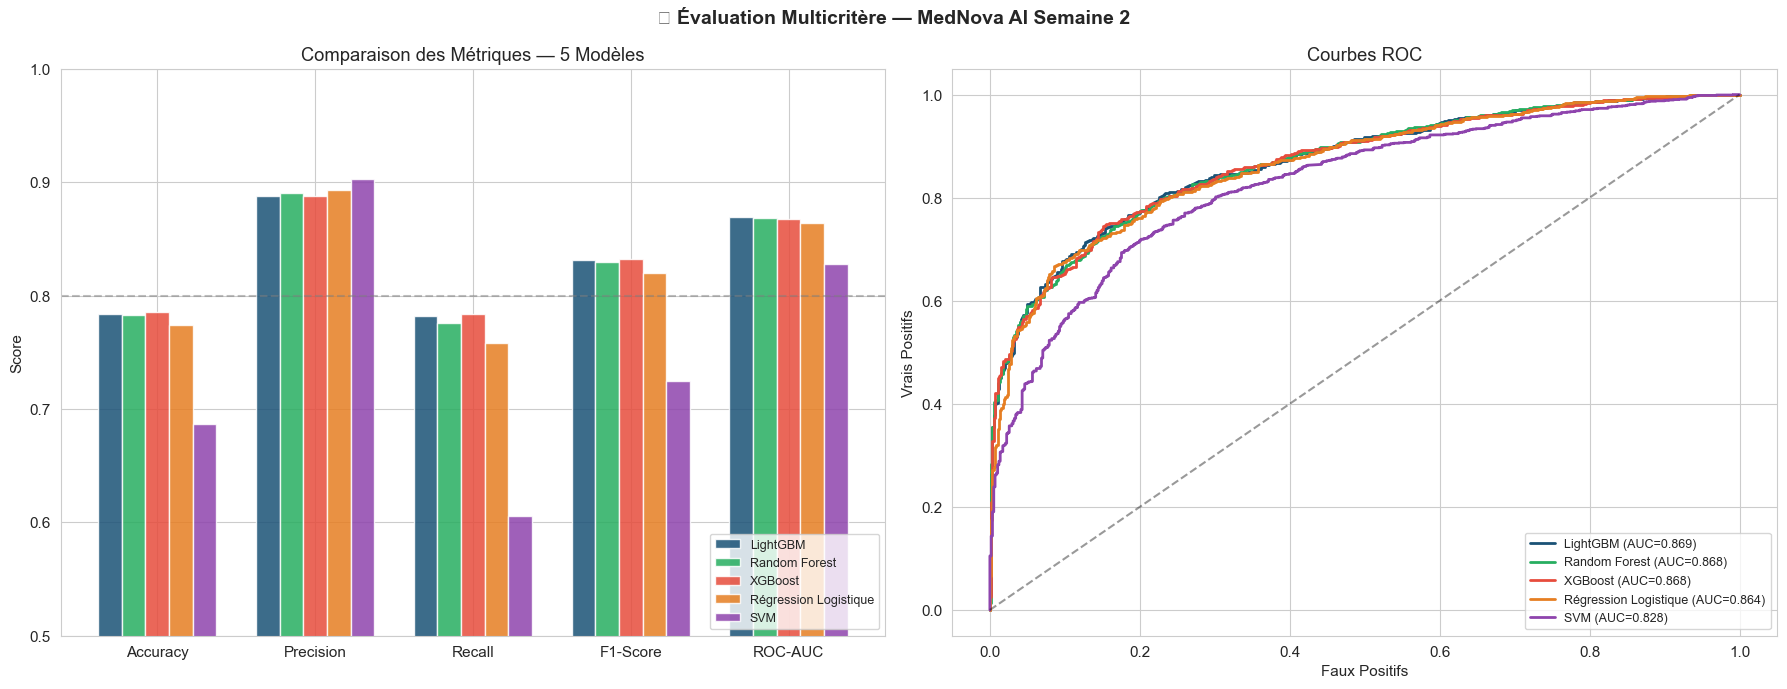

✅ Sauvegardé → data/model_comparison.png


In [36]:
# Barplot métriques + Courbes ROC
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
model_names = results_df.index.tolist()
colors_models = [MEDNOVA_BLUE, MEDNOVA_GREEN, MEDNOVA_RED, MEDNOVA_ORANGE, MEDNOVA_PURPLE]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

x = np.arange(len(metrics)); width = 0.15
for i, (model, color) in enumerate(zip(model_names, colors_models)):
    axes[0].bar(x+i*width, [results_df.loc[model,m] for m in metrics], width,
                label=model, color=color, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x+width*2); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.5, 1.0); axes[0].set_ylabel('Score')
axes[0].set_title('Comparaison des Métriques — 5 Modèles')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)

for model_name, color in zip(model_names, colors_models):
    y_prob = trained_models[model_name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                  label=f'{model_name} (AUC={results_df.loc[model_name,"ROC-AUC"]:.3f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].set_xlabel('Faux Positifs'); axes[1].set_ylabel('Vrais Positifs')
axes[1].set_title('Courbes ROC'); axes[1].legend(loc='lower right', fontsize=9)

plt.suptitle('📊 Évaluation Multicritère — MedNova AI Semaine 2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé → data/model_comparison.png')

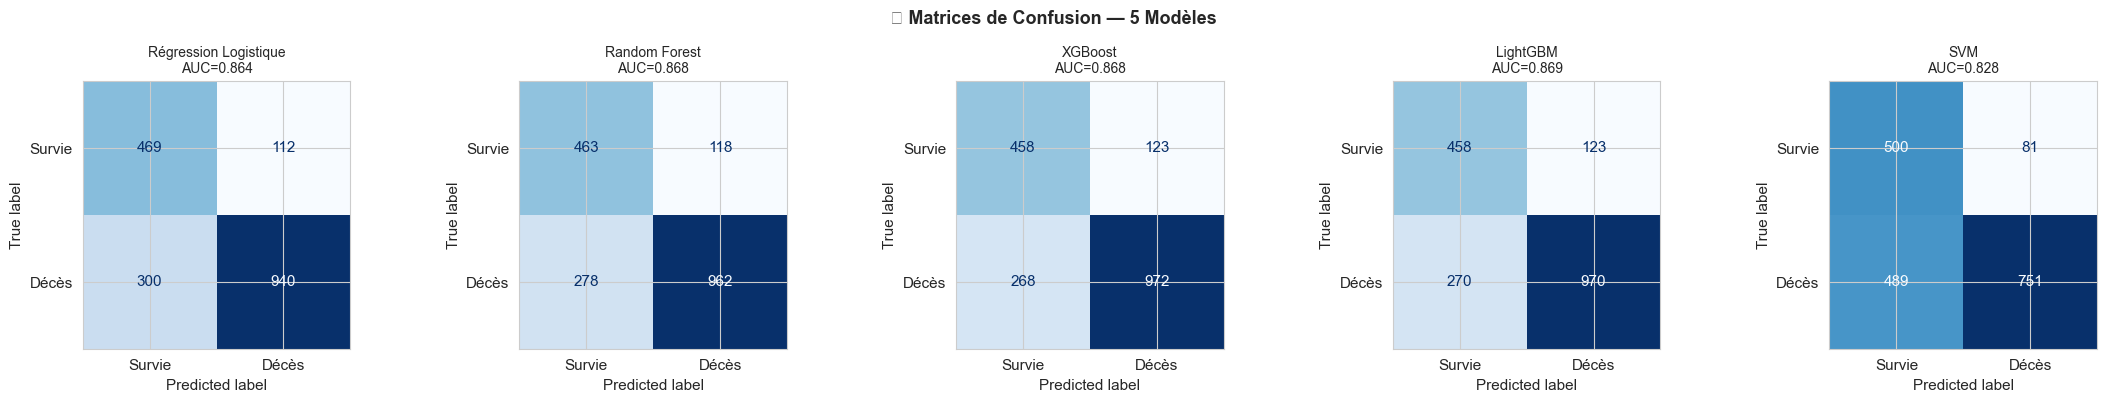

✅ Sauvegardé → data/confusion_matrices.png


In [37]:
# Matrices de confusion
fig, axes = plt.subplots(1, len(trained_models), figsize=(22, 4))
for i, (model_name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred),
                            display_labels=['Survie','Décès']).plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{model_name}\nAUC={results_df.loc[model_name,"ROC-AUC"]:.3f}', fontsize=10)
plt.suptitle('🔢 Matrices de Confusion — 5 Modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé → data/confusion_matrices.png')

🔄 Cross-validation 5-fold : LightGBM

ROC-AUC : 0.8648 ± 0.0053
F1-Score: 0.8248 ± 0.0023


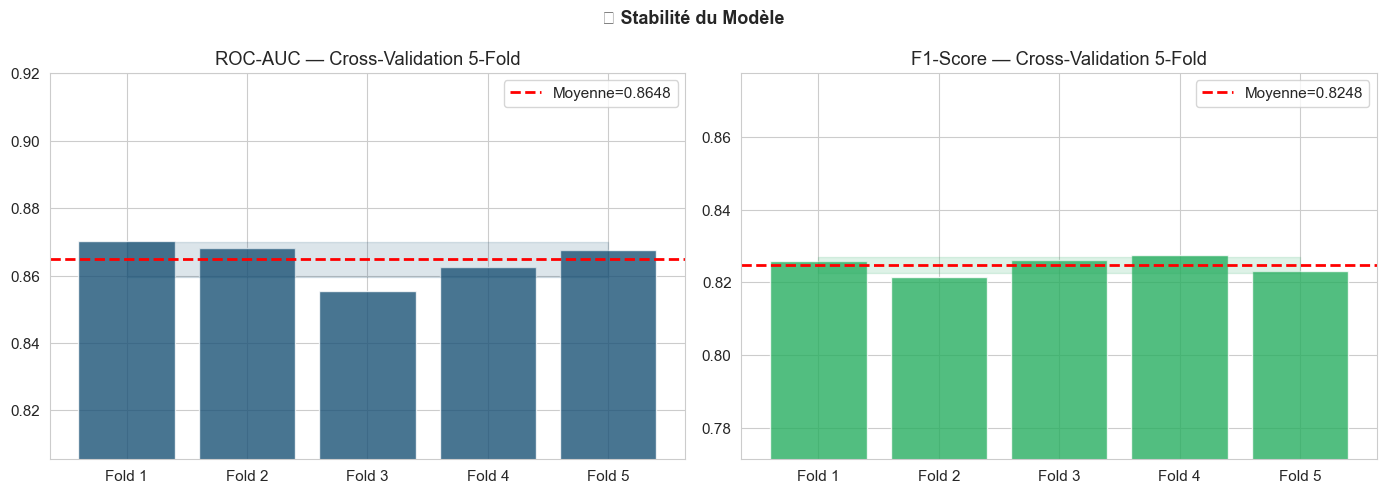

✅ Sauvegardé → data/cross_validation.png


In [38]:
# Cross-validation 5-fold
print(f'🔄 Cross-validation 5-fold : {best_model_name}\n')
best_model_cv = trained_models[best_model_name]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_all = np.vstack([X_train, X_test]); y_all = np.concatenate([y_train, y_test])
cv_auc = cross_val_score(best_model_cv, X_all, y_all, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(best_model_cv, X_all, y_all, cv=cv, scoring='f1',      n_jobs=-1)
print(f'ROC-AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'F1-Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scores, label, color in [(axes[0],cv_auc,'ROC-AUC',MEDNOVA_BLUE),(axes[1],cv_f1,'F1-Score',MEDNOVA_GREEN)]:
    ax.bar([f'Fold {i+1}' for i in range(len(scores))], scores, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne={scores.mean():.4f}')
    ax.fill_between(range(len(scores)), scores.mean()-scores.std(), scores.mean()+scores.std(), alpha=0.15, color=color)
    ax.set_ylim(max(0,scores.min()-0.05), min(1,scores.max()+0.05))
    ax.set_title(f'{label} — Cross-Validation 5-Fold'); ax.legend()
plt.suptitle('🔄 Stabilité du Modèle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'cross_validation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé → data/cross_validation.png')

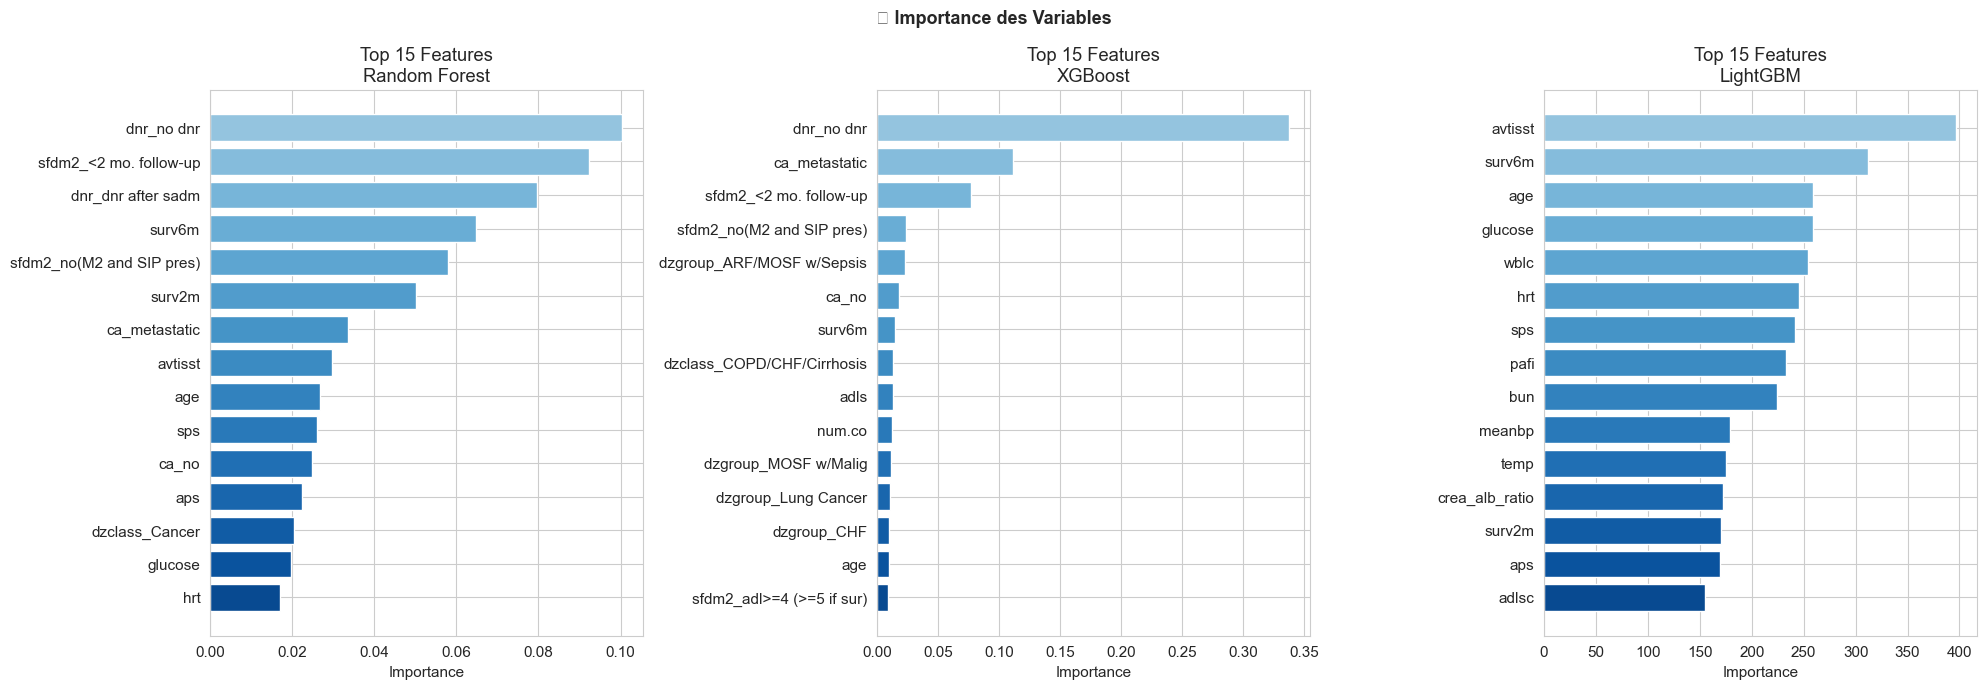

✅ Sauvegardé → data/feature_importance.png


In [39]:
# Feature importance
tree_models = {k:v for k,v in trained_models.items() if k in ['Random Forest','XGBoost','LightGBM']}
if tree_models:
    try:
        cat_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols_final).tolist()
    except: cat_feature_names = []
    feature_names = num_cols_final + cat_feature_names
    fig, axes = plt.subplots(1, len(tree_models), figsize=(20, 7))
    if len(tree_models)==1: axes=[axes]
    for i, (model_name, model) in enumerate(tree_models.items()):
        importances = model.feature_importances_
        n = min(len(importances), len(feature_names))
        feat_imp = pd.Series(importances[:n], index=feature_names[:n]).nlargest(15)
        axes[i].barh(feat_imp.index, feat_imp.values,
                      color=plt.cm.Blues(np.linspace(0.4,0.9,len(feat_imp))), edgecolor='white')
        axes[i].set_title(f'Top 15 Features\n{model_name}'); axes[i].set_xlabel('Importance'); axes[i].invert_yaxis()
    plt.suptitle('🏆 Importance des Variables', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Sauvegardé → data/feature_importance.png')

## 7. 💾 Sélection & Sauvegarde

In [40]:
best_model = trained_models[best_model_name]

print(f'🏆 MODÈLE SÉLECTIONNÉ : {best_model_name}')
print('─'*50)
print(classification_report(y_test, best_model.predict(X_test), target_names=['Survie','Décès']))

joblib.dump(best_model,   os.path.join(MODELS_DIR, 'best_model_treatment.pkl'))
joblib.dump(preprocessor, os.path.join(MODELS_DIR, 'preprocessor.pkl'))

metadata = {
    'model_name': best_model_name, 'target': TARGET,
    'features': feature_cols, 'num_cols': num_cols_final, 'cat_cols': cat_cols_final,
    'roc_auc' : float(results_df.loc[best_model_name,'ROC-AUC']),
    'f1_score': float(results_df.loc[best_model_name,'F1-Score']),
    'accuracy': float(results_df.loc[best_model_name,'Accuracy']),
    'train_size': int(X_train.shape[0]), 'test_size': int(X_test.shape[0]),
    'n_features_input': int(X_train.shape[1]),
    'death_rate_train': float(y_train.mean()),
}
with open(os.path.join(MODELS_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print('\n✅ Sauvegardés dans models/')
print('   📦 best_model_treatment.pkl')
print('   📦 preprocessor.pkl')
print('   📋 model_metadata.json')

🏆 MODÈLE SÉLECTIONNÉ : LightGBM
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      Survie       0.63      0.79      0.70       581
       Décès       0.89      0.78      0.83      1240

    accuracy                           0.78      1821
   macro avg       0.76      0.79      0.77      1821
weighted avg       0.81      0.78      0.79      1821


✅ Sauvegardés dans models/
   📦 best_model_treatment.pkl
   📦 preprocessor.pkl
   📋 model_metadata.json


## 8. 📋 Rapport final

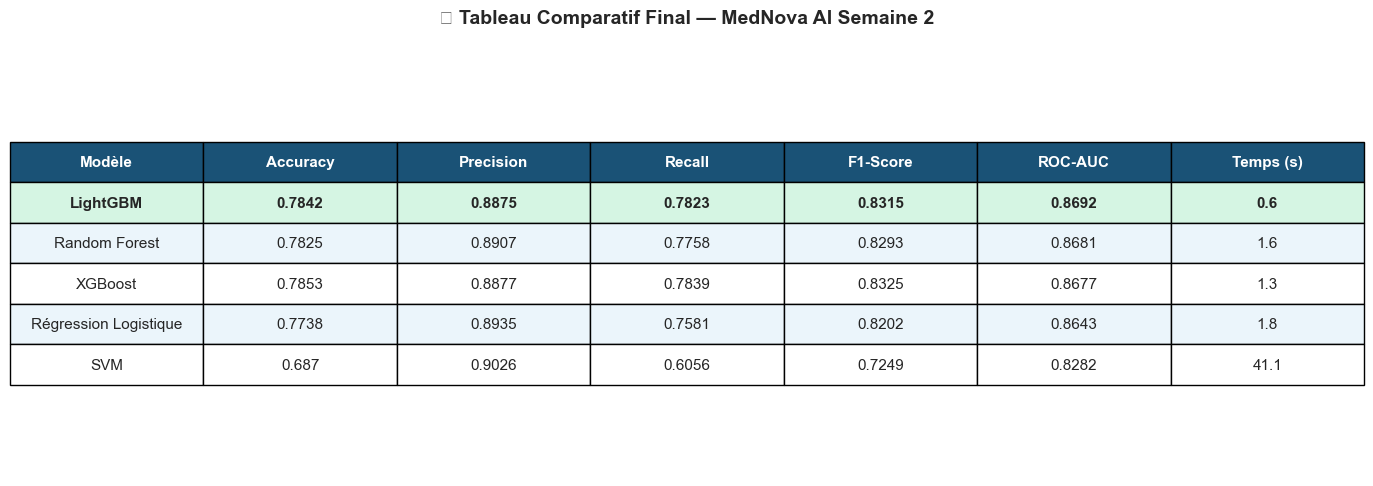

✅ Sauvegardé → data/final_comparison_table.png


In [41]:
# Tableau comparatif visuel
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
display_df = results_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC','Temps (s)']].reset_index()
table = ax.table(cellText=display_df.values, colLabels=display_df.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.3, 2.2)
for j in range(len(display_df.columns)):
    table[0,j].set_facecolor(MEDNOVA_BLUE); table[0,j].set_text_props(color='white', fontweight='bold')
best_idx = display_df[display_df['Modèle']==best_model_name].index[0]+1
for j in range(len(display_df.columns)):
    table[best_idx,j].set_facecolor('#D5F5E3'); table[best_idx,j].set_text_props(fontweight='bold')
for i in range(1, len(display_df)+1):
    if i != best_idx:
        for j in range(len(display_df.columns)): table[i,j].set_facecolor('#EBF5FB' if i%2==0 else 'white')
plt.title('🏆 Tableau Comparatif Final — MedNova AI Semaine 2', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'final_comparison_table.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé → data/final_comparison_table.png')

In [35]:
print('='*65)
print('  📋 RAPPORT FINAL — SEMAINE 2 — MedNova AI')
print('='*65)
print(f'\n🔧 PRÉTRAITEMENT')
print(f'   Imputation  : Médiane (num) + Mode (cat)')
print(f'   Winsorizing : 1%-99%  |  Scaler : RobustScaler  |  Encoding : OneHot')
print(f'   New features: organ_failure_score, crea_alb_ratio, comorbidity_count, age_group')
print(f'\n✂️  SPLIT  Train: {X_train.shape[0]:,} (80%) | Test: {X_test.shape[0]:,} (20%)')
print(f'\n🤖 RÉSULTATS :')
for name, row in results_df.iterrows():
    marker = '🏆' if name == best_model_name else '  '
    print(f'   {marker} {name:25s} | AUC={row["ROC-AUC"]:.4f} | F1={row["F1-Score"]:.4f}')
print(f'\n📂 data/')
for f in sorted(os.listdir(DATA_DIR)): print(f'   • {f}')
print(f'\n📂 models/')
for f in sorted(os.listdir(MODELS_DIR)): print(f'   • {f}')
print(f'\n🚀 Prochaine étape : Semaine 3 — Complications + SHAP + What-If')
print('='*65)

  📋 RAPPORT FINAL — SEMAINE 2 — MedNova AI

🔧 PRÉTRAITEMENT
   Imputation  : Médiane (num) + Mode (cat)
   Winsorizing : 1%-99%  |  Scaler : RobustScaler  |  Encoding : OneHot
   New features: organ_failure_score, crea_alb_ratio, comorbidity_count, age_group

✂️  SPLIT  Train: 7,284 (80%) | Test: 1,821 (20%)

🤖 RÉSULTATS :
   🏆 LightGBM                  | AUC=0.8692 | F1=0.8315
      Random Forest             | AUC=0.8681 | F1=0.8293
      XGBoost                   | AUC=0.8677 | F1=0.8325
      Régression Logistique     | AUC=0.8643 | F1=0.8202
      SVM                       | AUC=0.8282 | F1=0.7249

📂 data/
   • boxplots_vitals.png
   • categorical_analysis.png
   • confusion_matrices.png
   • correlation_matrix.png
   • cross_validation.png
   • feature_correlation_target.png
   • feature_importance.png
   • final_comparison_table.png
   • missing_values_analysis.png
   • model_comparison.png
   • outliers_detection.png
   • scatter_analysis.png
   • support2.csv
   • support2_raw.